# ML2 + ML3 — Model Training

**Objective:** Train a LinearRegression and a RandomForestRegressor on the engineered features, select the best model by cross-validated R², and export it for the API.

**Input:** `data/training_features.parquet` (output of `01_eda_feature_engineering.ipynb`)  
**Output:** `models/model.pkl`, `models/metadata.json`  
**Validation:** R² > 0.65, no data leakage (temporal split only)

In [3]:
import os
import json
import pickle
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')

# ── Tune this if test R² is too low (try 0.85 or 0.90) ─────────────────────
TRAIN_RATIO = 0.85

FEATURE_COLS = [
    'hour', 'day_of_week', 'day_of_month', 'is_weekend', 'is_peak_hour',
    'fill_rate_1h_ago', 'fill_rate_24h_ago', 'fill_rate_7d_ago',
    'fill_rate_24h_avg', 'fill_rate_7d_avg', 'fill_rate_change_rate',
    'capacity_liters', 'type_id', 'density_km2',
]

print('Libraries loaded')
print(f'TRAIN_RATIO = {TRAIN_RATIO}')

Libraries loaded
TRAIN_RATIO = 0.85


## 1. Load & Inspect Dataset

In [4]:
df = pd.read_parquet('data/training_features.parquet')

# pandas 2.x stores datetime as DatetimeArray (ExtensionArray) regardless of astype —
# its _values_for_argsort() / isna() return mismatched lengths, crashing sort_values.
# to_numpy() gives a plain numpy datetime64 array; numpy argsort has no such bug.
order = df['measured_at'].to_numpy().argsort(kind='stable')
df = df.iloc[order].reset_index(drop=True)

if len(df) == 0:
    raise ValueError(
        'data/training_features.parquet is empty.\n'
        'Re-run 01_eda_feature_engineering.ipynb — it will tell you why rows were dropped.\n'
        'Most likely cause: fill_history has < 8 days of data per container.'
    )

print(f'Total rows   : {len(df):,}')
print(f'Date range   : {df.measured_at.min()} → {df.measured_at.max()}')
print(f'Containers   : {df.container_id.nunique():,}')
print(f'Target range : {df.target.min():.1f} – {df.target.max():.1f}')
df.head()

Total rows   : 6,251,787
Date range   : 2026-05-21 16:10:00 → 2026-06-12 16:00:00
Containers   : 2,000
Target range : 1.6 – 80.0


,hour,day_of_week,day_of_month,is_weekend,is_peak_hour,fill_rate_1h_ago,fill_rate_24h_ago,fill_rate_7d_ago,fill_rate_24h_avg,fill_rate_7d_avg,fill_rate_change_rate,capacity_liters,type_id,density_km2,target,container_id,measured_at
0,16,3,21,0,0,57.43,23.71,29.56,41.751458,36.993224,0.263333,1000.0,3,206.532441,20.83,6,2026-05-21 16:10:00
1,16,3,21,0,0,57.44,23.95,29.75,41.996597,37.022440,0.313333,1000.0,3,206.532441,21.07,6,2026-05-21 16:20:00
2,16,3,21,0,0,6.86,54.29,31.69,63.640556,44.596141,0.151667,750.0,1,206.532441,38.48,191,2026-05-21 16:20:00
3,16,3,21,0,0,13.71,31.40,5.21,44.455486,36.269921,0.360000,750.0,2,55.595054,63.63,954,2026-05-21 16:20:00
4,16,3,21,0,0,50.96,60.79,5.48,31.312431,35.996111,0.531667,500.0,5,55.595054,48.03,1067,2026-05-21 16:20:00


## 2. Temporal Train / Test Split

**Do not use `train_test_split(shuffle=True)`** — this is time-series data.
The test set must be the **most recent 20%** to avoid future leakage.

In [5]:
split_idx = int(len(df) * TRAIN_RATIO)
df_train = df.iloc[:split_idx]
df_test  = df.iloc[split_idx:]

X_train, y_train = df_train[FEATURE_COLS], df_train['target']
X_test,  y_test  = df_test[FEATURE_COLS],  df_test['target']

print(f'Train : {len(df_train):,} rows  ({df_train.measured_at.min()} → {df_train.measured_at.max()})')
print(f'Test  : {len(df_test):,} rows  ({df_test.measured_at.min()} → {df_test.measured_at.max()})')

Train : 5,314,018 rows  (2026-05-21 16:10:00 → 2026-06-09 08:50:00)
Test  : 937,769 rows  (2026-06-09 08:50:00 → 2026-06-12 16:00:00)


## 3. Preprocessor & Cross-Validation Setup

In [6]:
categorical = ['type_id']
numerical   = [c for c in FEATURE_COLS if c not in categorical]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                          numerical),
    ('cat', OneHotEncoder(handle_unknown='ignore'),    categorical),
])

tscv = TimeSeriesSplit(n_splits=5)
print(f'Numerical features  : {len(numerical)}')
print(f'Categorical features: {len(categorical)}')

Numerical features  : 13
Categorical features: 1


## 4. Linear Regression

In [7]:
lr_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', LinearRegression()),
])

lr_pipe.fit(X_train, y_train)

lr_cv_scores = cross_val_score(lr_pipe, X_train, y_train, cv=tscv, scoring='r2')
lr_cv_r2 = lr_cv_scores.mean()

lr_pred   = lr_pipe.predict(X_test)
lr_rmse   = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae    = mean_absolute_error(y_test, lr_pred)
lr_test_r2 = r2_score(y_test, lr_pred)

print(f'LinearRegression  CV R² (mean ± std): {lr_cv_r2:.3f} ± {lr_cv_scores.std():.3f}')
print(f'LinearRegression  Test  RMSE={lr_rmse:.2f}  MAE={lr_mae:.2f}  R²={lr_test_r2:.3f}')

LinearRegression  CV R² (mean ± std): -28536029322316992512.000 ± 57072058644633993216.000
LinearRegression  Test  RMSE=17.90  MAE=13.87  R²=0.199


## 5. Random Forest

In [8]:
rf_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=20,
        n_jobs=-1,
        random_state=42,
    )),
])

rf_pipe.fit(X_train, y_train)

rf_cv_scores = cross_val_score(rf_pipe, X_train, y_train, cv=tscv, scoring='r2')
rf_cv_r2 = rf_cv_scores.mean()

rf_pred    = rf_pipe.predict(X_test)
rf_rmse    = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae     = mean_absolute_error(y_test, rf_pred)
rf_test_r2 = r2_score(y_test, rf_pred)

print(f'RandomForest  CV R² (mean ± std): {rf_cv_r2:.3f} ± {rf_cv_scores.std():.3f}')
print(f'RandomForest  Test  RMSE={rf_rmse:.2f}  MAE={rf_mae:.2f}  R²={rf_test_r2:.3f}')

RandomForest  CV R² (mean ± std): 0.633 ± 0.054
RandomForest  Test  RMSE=11.34  MAE=6.61  R²=0.678


## 6. HistGradientBoosting

Native NaN support — no `StandardScaler`/`OneHotEncoder` needed. Typically generalises better than RF on tabular time-series data.

In [9]:
# HistGradientBoosting handles mixed types natively — no preprocessor needed
hgb_pipe = Pipeline([
    ('model', HistGradientBoostingRegressor(
        max_iter=300,
        max_depth=6,
        min_samples_leaf=20,
        learning_rate=0.05,
        random_state=42,
    )),
])

hgb_pipe.fit(X_train, y_train)

hgb_cv_scores = cross_val_score(hgb_pipe, X_train, y_train, cv=tscv, scoring='r2')
hgb_cv_r2 = hgb_cv_scores.mean()

hgb_pred    = hgb_pipe.predict(X_test)
hgb_rmse    = np.sqrt(mean_squared_error(y_test, hgb_pred))
hgb_mae     = mean_absolute_error(y_test, hgb_pred)
hgb_test_r2 = r2_score(y_test, hgb_pred)

print(f'HistGradientBoosting  CV R² (mean ± std): {hgb_cv_r2:.3f} ± {hgb_cv_scores.std():.3f}')
print(f'HistGradientBoosting  Test  RMSE={hgb_rmse:.2f}  MAE={hgb_mae:.2f}  R²={hgb_test_r2:.3f}')

HistGradientBoosting  CV R² (mean ± std): 0.718 ± 0.028
HistGradientBoosting  Test  RMSE=9.95  MAE=5.47  R²=0.753


## 7. Model Comparison

In [10]:
results = pd.DataFrame([
    {'Model': 'LinearRegression',    'CV R²': lr_cv_r2,  'Test R²': lr_test_r2,
     'RMSE': lr_rmse,  'MAE': lr_mae},
    {'Model': 'RandomForest',        'CV R²': rf_cv_r2,  'Test R²': rf_test_r2,
     'RMSE': rf_rmse,  'MAE': rf_mae},
    {'Model': 'HistGradientBoosting','CV R²': hgb_cv_r2, 'Test R²': hgb_test_r2,
     'RMSE': hgb_rmse, 'MAE': hgb_mae},
]).set_index('Model')

print(f'\n=== Model comparison (TRAIN_RATIO={TRAIN_RATIO}) ===')
print(results.round(3))

print(f'\nTarget thresholds: RMSE < 10, MAE < 7, R² > 0.65')
for name, rmse, mae, r2 in [
    ('LR',  lr_rmse,  lr_mae,  lr_test_r2),
    ('RF',  rf_rmse,  rf_mae,  rf_test_r2),
    ('HGB', hgb_rmse, hgb_mae, hgb_test_r2),
]:
    ok = rmse < 10 and mae < 7 and r2 > 0.65
    print(f'  {name}: {"✅ PASS" if ok else "❌ FAIL"}')


=== Model comparison (TRAIN_RATIO=0.85) ===
                             CV R²  Test R²    RMSE     MAE
Model                                                      
LinearRegression     -2.853603e+19    0.199  17.903  13.873
RandomForest          6.330000e-01    0.678  11.342   6.609
HistGradientBoosting  7.180000e-01    0.753   9.949   5.468

Target thresholds: RMSE < 10, MAE < 7, R² > 0.65
  LR: ❌ FAIL
  RF: ❌ FAIL
  HGB: ✅ PASS


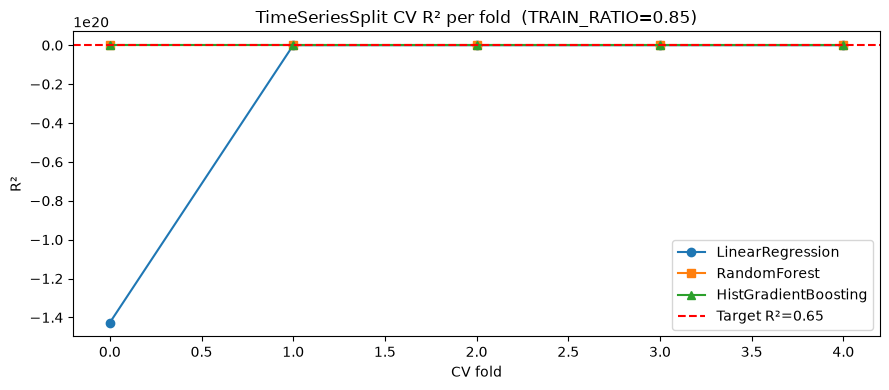

In [11]:
# CV score distributions
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(lr_cv_scores))
ax.plot(x, lr_cv_scores,  marker='o', label='LinearRegression')
ax.plot(x, rf_cv_scores,  marker='s', label='RandomForest')
ax.plot(x, hgb_cv_scores, marker='^', label='HistGradientBoosting')
ax.axhline(0.65, color='red', linestyle='--', label='Target R²=0.65')
ax.set_xlabel('CV fold')
ax.set_ylabel('R²')
ax.set_title(f'TimeSeriesSplit CV R² per fold  (TRAIN_RATIO={TRAIN_RATIO})')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Export Best Model

In [12]:
candidates = [
    ('lr',  lr_cv_r2,  lr_pipe,  lr_test_r2,  lr_rmse,  lr_mae),
    ('rf',  rf_cv_r2,  rf_pipe,  rf_test_r2,  rf_rmse,  rf_mae),
    ('hgb', hgb_cv_r2, hgb_pipe, hgb_test_r2, hgb_rmse, hgb_mae),
]
best_name, best_cv_r2, best_model, best_test_r2, best_rmse, best_mae = max(
    candidates, key=lambda x: x[1]
)

os.makedirs('models', exist_ok=True)

with open('models/model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

metadata = {
    'version':       f'{best_name}_v1.0',
    'trained_at':    datetime.now(timezone.utc).isoformat(),
    'feature_cols':  FEATURE_COLS,
    'train_ratio':   TRAIN_RATIO,
    'cv_r2':         round(best_cv_r2,   4),
    'test_r2':       round(best_test_r2, 4),
    'test_rmse':     round(best_rmse,    4),
    'test_mae':      round(best_mae,     4),
    'model_type':    best_name,
    'train_rows':    len(df_train),
    'test_rows':     len(df_test),
    'n_features':    len(FEATURE_COLS),
}
with open('models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'Saved models/model.pkl')
print(f'Saved models/metadata.json')
print(f'Best model : {best_name}_v1.0  CV R²={best_cv_r2:.3f}  Test R²={best_test_r2:.3f}')
print(f'\nDone — proceed to 03_evaluation.ipynb')

Saved models/model.pkl
Saved models/metadata.json
Best model : hgb_v1.0  CV R²=0.718  Test R²=0.753

Done — proceed to 03_evaluation.ipynb
